# Final Project: Data Ethics and Policy

Christy Hsu (Georgetown University)

## Abstract

This project looked into an attempt in the fifties that set out to measure individual tolerance and use that measure to evaluate the impact the anti-Communism Cold War agenda—both abroad and at home—had on U.S. citizens. I saw the picking up of this 70-year-old survey data, and the analysis that accompanied it, as a chance to stroll through the data ethics concerns that can arise when holding the hope to learn about the world from data

## Introduction

The online poll data library host by Roper Center was where I first came across the Stouffer Study of 1954 *Communism, Conformity, and Civil Liberties: A Cross-Section of the Nation Speaks Its Mind* by Samuel Andrew Stouffer\[@fundfortherepublicCommunismConformityAmp2020\]And, I gained access to the entire dataset on ICPSR\[@stoufferCommunismConformityCivil1992\]

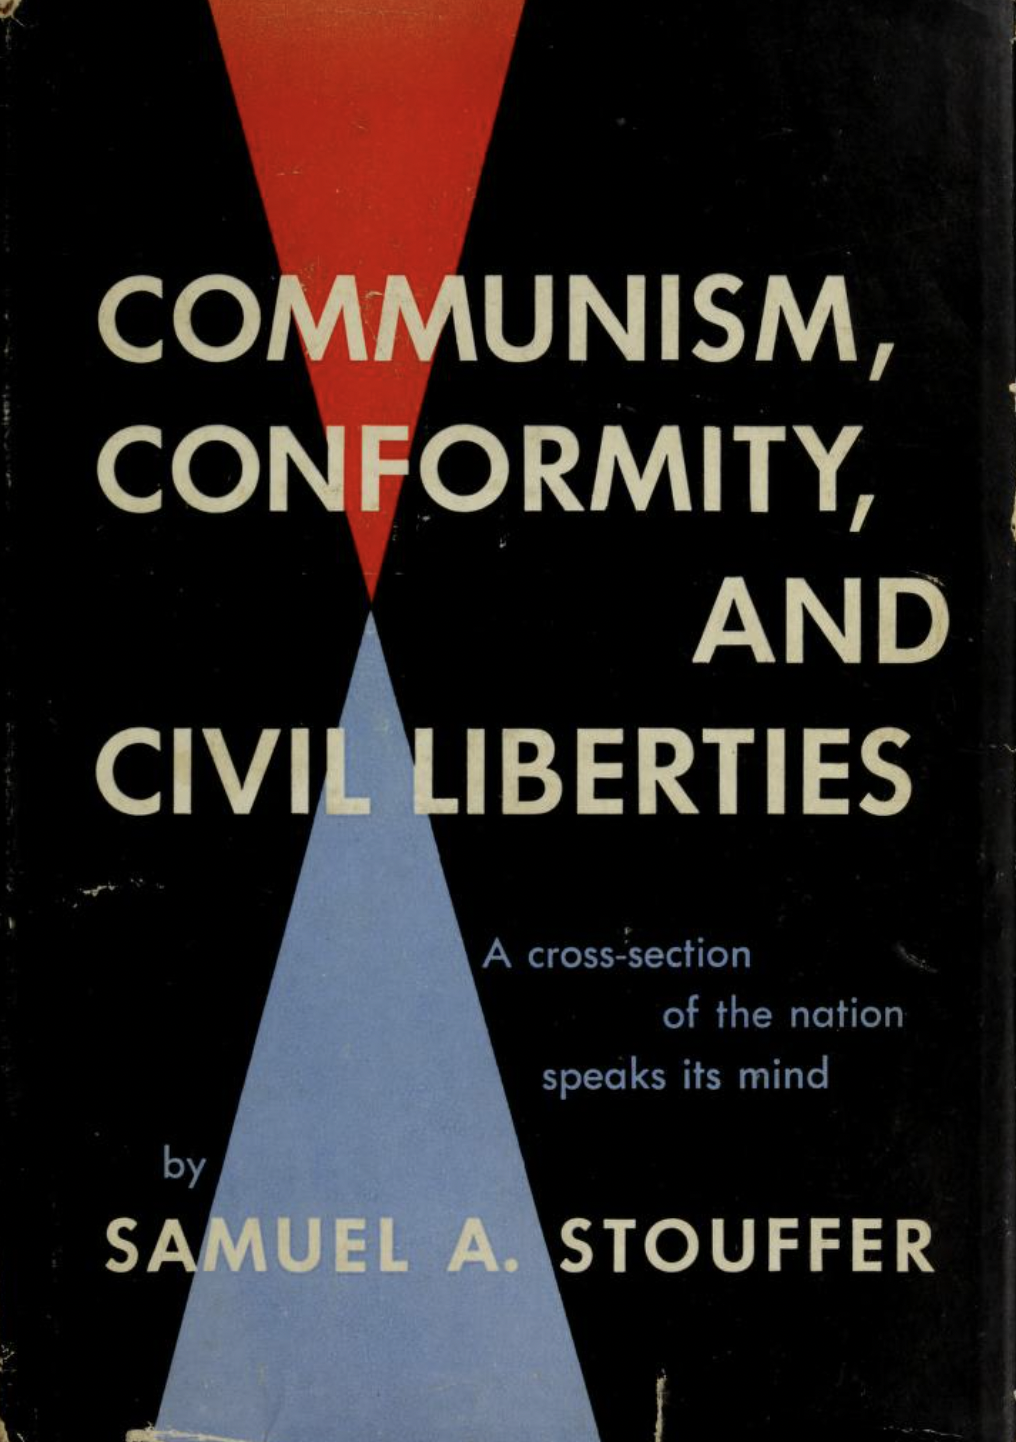{ width="50%"}

I found Stouffer’s attempt in the fifties to design public opion polls and, construct an innovative way of measuring the latent properties tolerance and fear at the individual level very interesting. The tolerance scale and the perception of internal communist danger scale are not included in the data, thus a major part of this project involved returning these two target variables in order to complete the picture and reproduce that basis on which Stouffer built his arguments. I learned much from this practice of reading and researching that past effort into conceptualizing and operationalizing tolerance and fear, and got my hands dirty to really apply those framings and methods to the data. It gave me a chance to reflect on the many artistic and arbitrary decisions that the researcher made throughout this data analysis process.

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.3.0
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Loading required package: Matrix

Attaching package: 'Matrix'

The following objects are masked from 'package:tidyr':

    expand, pack, unpack

Loaded glmnet 4.1-8

Loading required package: lattice

Attaching package: 'caret'

The following object is masked from 'package:purrr':

    lift

In [ ]:
project_dir <- Sys.getenv("QUARTO_PROJECT_DIR")
data_dir <- file.path(project_dir, "data")

## Harvesting from Historical Data Collection Effort: A More Friendly Format

Complying ICPSR’s redistribution policy, the converted data files are not provided here. Instead, the author provides STATA .do and .dct files, which were constructed based on the reading of the codebook. Please down the the dataset in ASCII format from ICPSR and should be able to apply to decode the .txt files from both samples.\[@stoufferCommunismConformityCivil1992\]

    ├── read-ascii-files
    │   ├── gp-decode.do
    │   ├── lead-decode.do
    │   ├── sample1.dct
    │   └── sample2.dct

## Return target variables

The tolerance that Stouffer argued upon.\[@stouffer1955communism, pp.262-269\]

#### Prepare the `code_df` data frame

1.  Cleaning column names and binding the two samples

In [ ]:
# read the coded csv files for both samples
# public_df <- read_csv('data/converted/coded-public.csv')
# lead_df <- read_csv('data/converted/coded-leader.csv')
public_df <- read_csv(file.path(data_dir, "converted", "coded-public.csv"))

Rows: 4933 Columns: 152
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (152): v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 1500 Columns: 151
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (151): v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

In [ ]:
# for the variables from 150 on distinguish those from public sample and those from leader sample since they represent different survey questions

public_df <- public_df |>
  rename(
    public_v150 = v150,
    public_v151 = v151,
    public_v152 = v152
  )
lead_df <- lead_df |>
  rename(
    lead_v150 = v150,
    lead_v151 = v151
  )

# sample specific questions to the other sample, I filled the empty entries with 54
lead_df <- lead_df |>
  mutate(public_v150 = 54, public_v151 = 54, public_v152 = 54)
public_df <- public_df |>
  mutate(lead_v150 = 54, lead_v151 = 54)

#### Adding Binary and Ternary Variables `leader`,`interested` and `categorizer`: these are the variables that Stouffer specified in his book as ways to divide the respondents and make comparisons.

In [ ]:
code_df <- bind_rows(public_df, lead_df)
code_df <- code_df |> mutate(leader = case_when(
  lead_v150 == 54 ~ 0,
  TRUE ~ 1
))
code_df |> count(leader)

    leader      n
  -------- ------
         0   4933
         1   1500


In [ ]:
code_df <- code_df |> mutate(interested = case_when(
    v123 == 1 ~ 'more',
    v123 == 2 ~ 'more',
    TRUE ~ 'less'
)
)
code_df |> count(leader, interested) |> group_by(leader) |> mutate(pct = n / sum(n) * 100) |> ungroup()

    leader interested        n        pct
  -------- ------------ ------ ----------
         0 less           2155   43.68538
         0 more           2778   56.31462
         1 less            210   14.00000
         1 more           1290   86.00000


In [ ]:
code_df <- code_df |> mutate(categorizer = case_when(
  v127 %in% c(1, 2) ~ 'agree',
  v127 == 8 ~'dont know',
  TRUE ~ 'disagree'
))

In [ ]:
code_df |> count(leader, categorizer)|> group_by(leader) |> mutate(pct = n / sum(n) * 100) |> ungroup()

    leader categorizer        n         pct
  -------- ------------- ------ -----------
         0 agree           3127   63.389418
         0 disagree        1495   30.306102
         0 dont know        311    6.304480
         1 agree            806   53.733333
         1 disagree         669   44.600000
         1 dont know         25    1.666667


## Scale1: Willingness to Tolerate Nonconformist

#### Conceptual Tolerance and Operational Tolerance

The questionnaires used to rank respondents into six tolerance groups focused on four types of nonconformists:

-   A person who is against all churches and religion (atheist)
-   A person who favors government ownership (socialist)
-   An alleged communist (someone whose loyalty has been questioned by a Congressional Committee but swears under oath they have never been a communist)
-   An admitted communist

respondent were asked about their approval of 3 types of disposition against the above nonconfromist, and whether they agree or disagree the limitation or deprivation of the nonconformist’s civil liberties, for example:

1.  Freedom speech:

    -   “If \_\_\_ wants to make a speech in your community, should he be allowed to speak or not?”

2.  Book censor:

    -   “Suppose he wrote a book that is in your public library. Somebody in your community suggests the book should be removed. Would you favor removing it, or not?”

3.  Employment:

    -   Should a radio singer who is a nonconformist be fired or not?
    -   Should a college or university teacher be fired or not?
    -   Should a high school teacher be fired or not?
    -   Should someone working in a defense plant be fired or not?
    -   Should a store clerk be fired or not?

4.  Boycott:

    -   “Suppose the radio program he is on advertises a brand of soap. Somebody in your community suggests you stop buying that soap. Would you stop or not?”

#### 0 to 5: Scaling Individual Tolerance

I ran into many challenges replicating Stouffer’s results. Both the overall proportions across tolerance rankings, was unable to reproduce the group counts applying further breakdowns, such as by age, region, education, thus for comparison.

In [ ]:
code_df <- code_df |> mutate(tolerance_group = NA_character_)
tolerance_items <- c(
  'v100', 'v101', 'v102',
  'v104', 'v32', 'v34',
  'v103', 'v35', 'v37',
  'v108', 'v109', 'v113',
  'v106', 'v107', 'v110'
)

In [ ]:
# df0 <- code_df |> filter(
#   ((v100 == 1) + (v101 == 5) + (v102 == 5) < 2) &
#   ((v104 == 5) + (v32 == 1) + (v34 == 5) < 2) &
#   ((v103 == 5) + (v35 == 1) + (v37 == 5) < 2) &
#   ((v108 == 5) + (v109 == 1) + (v113 == 5) < 2) &
#   ((v106 == 5) + (v107 == 5) + (v110 == 5) + (v106 == 8) + (v107 == 8) + (v110 == 8) < 2)) |> dplyr::select(
#     all_of(tolerance_items))
# df0 |> View()

In [ ]:
## sanity check
df5 <- code_df |> filter(
  ((v100 == 1) + (v101 == 5) + (v102 == 5) >= 2) &
  ((v104 == 5) + (v32 == 1) + (v34 == 5) >= 2) &
  ((v103 == 5) + (v35 == 1) + (v37 == 5) >= 2) &
  ((v108 == 5) + (v109 == 1) + (v113 == 5) >= 2) &
  ((v106 == 5) + (v107 == 5) + (v110 == 5) + (v106 == 8) + (v107 == 8) + (v110 == 8) >= 2)) |> dplyr::select(
    all_of(tolerance_items))
# df5
df3 <- code_df |> filter(!((v104 == 5) + (v32 == 1) + (v34 == 5) >= 2)) |> filter(
  ((v103 == 5) + (v35 == 1) + (v37 == 5) >= 2) &
  ((v108 == 5) + (v109 == 1) + (v113 == 5) >= 2) &
  ((v106 == 5) + (v107 == 5) + (v110 == 5) + (v106 == 8) + (v107 == 8) + (v110 == 8) >= 2)) |> dplyr::select(
    all_of(tolerance_items))
# df3 |> View()

In [ ]:
code_df <- code_df |> mutate(tolerance_group = NA_character_)

condition_filter <- function(df, condition, group_name){
  df <- df |> mutate(
    tolerance_group = case_when(
      is.na(tolerance_group) & !!rlang::enquo(condition) ~ group_name,
      TRUE ~ tolerance_group
    )
  )
  return(df)
}

In [ ]:
code_df <- code_df |> condition_filter(
  ((v100 == 1) + (v101 == 5) + (v102 == 5) >= 2) & 
  ((v104 == 5) + (v32 == 1) + (v34 == 5) >= 2) & 
  ((v103 == 5) + (v35 == 1) + (v37 == 5) >= 2) &
  ((v108 == 5) + (v109 == 1) + (v113 == 5) >= 2) &
  ((v106 == 5) + (v107 == 5) + (v110 == 5) + (v106 == 8) + (v107 == 8) + (v110 == 8) >= 2),
  "tolerance5"
)
code_df <- code_df |> condition_filter(
  ((v104 == 5) + (v32 == 1) + (v34 == 5) >= 2) & 
  ((v103 == 5) + (v35 == 1) + (v37 == 5) >= 2) &
  ((v108 == 5) + (v109 == 1) + (v113 == 5) >= 2) &
  ((v106 == 5) + (v107 == 5) + (v110 == 5) + (v106 == 8) + (v107 == 8) + (v110 == 8) >= 2),
  "tolerance4"
)
code_df <- code_df |> condition_filter(
  ((v103 == 5) + (v35 == 1) + (v37 == 5) >= 2) &
  ((v108 == 5) + (v109 == 1) + (v113 == 5) >= 2) &
  ((v106 == 5) + (v107 == 5) + (v110 == 5) + (v106 == 8) + (v107 == 8) + (v110 == 8) >= 2),
  "tolerance3"
)
code_df <- code_df |> condition_filter(
  ((v108 == 5) + (v109 == 1) + (v113 == 5) >= 2) &
  ((v106 == 5) + (v107 == 5) + (v110 == 5) + (v106 == 8) + (v107 == 8) + (v110 == 8) >= 2),
  "tolerance2"
)
code_df <- code_df |> condition_filter(
  ((v106 == 5) + (v107 == 5) + (v110 == 5) + (v106 == 8) + (v107 == 8) + (v110 == 8) >= 2),
  "tolerance1"
)
code_df <- code_df |> mutate(
  tolerance_group = ifelse(
    is.na(tolerance_group), "tolerance0", tolerance_group
    )
  )

In [ ]:
code_df |> count(leader, tolerance_group) |> group_by(leader) |> mutate(pct = n / sum(n) * 100) |> ungroup()

    leader tolerance_group        n         pct
  -------- ----------------- ------ -----------
         0 tolerance0           651   13.196838
         0 tolerance1           871   17.656598
         0 tolerance2          1263   25.603081
         0 tolerance3           951   19.278330
         0 tolerance4           395    8.007298
         0 tolerance5           802   16.257855
         1 tolerance0            79    5.266667
         1 tolerance1           182   12.133333
         1 tolerance2           180   12.000000
         1 tolerance3           246   16.400000
         1 tolerance4           205   13.666667
         1 tolerance5           608   40.533333


In [ ]:
code_df |> count(tolerance_group)

  tolerance_group        n
  ----------------- ------
  tolerance0           730
  tolerance1          1053
  tolerance2          1443
  tolerance3          1197
  tolerance4           600
  tolerance5          1410


#### Broader Tolerance Rank Groups: `less tolerant`, `in-between` and `more tolerant`

In [ ]:
code_df <- code_df |> 
  mutate(tolerance_broader0 = case_when(
    tolerance_group %in% c('tolerance0', 'tolerance1') ~ 'less tolerant',
    tolerance_group %in% c('tolerance2', 'tolerance3') ~ 'in between',
    TRUE ~ 'more tolerant'
  )) |>
  mutate(tolerance_broader0 = factor(
    tolerance_broader0,levels = c('more tolerant', 'in between', 'less tolerant'), ordered = TRUE
    ))

In [ ]:
code_df |> filter(leader == 1) |> count(tolerance_broader0) |> mutate(pct = (n / sum(n)) * 100)

  tolerance_broader0       n    pct
  -------------------- ----- ------
  more tolerant          813   54.2
  in between             426   28.4
  less tolerant          261   17.4


#### Attempt2

Allowing some inconsistency?

In [ ]:
library(rlang)


Attaching package: 'rlang'

The following objects are masked from 'package:purrr':

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice

In [ ]:
code_df <- assign_tolerance(code_df)
code_df |> count(tolerance)

  tolerance         n
  ------------ ------
  tolerance0      674
  tolerance1      530
  tolerance2     1334
  tolerance3     1229
  tolerance4      807
  tolerance5     1859


In [ ]:
code_df |> count(leader, tolerance) |> group_by(leader) |> mutate(pct = n / sum(n) * 100) |> ungroup()

    leader tolerance         n         pct
  -------- ------------ ------ -----------
         0 tolerance0      604   12.244070
         0 tolerance1      491    9.953375
         0 tolerance2     1179   23.900264
         0 tolerance3      993   20.129738
         0 tolerance4      554   11.230488
         0 tolerance5     1112   22.542064
         1 tolerance0       70    4.666667
         1 tolerance1       39    2.600000
         1 tolerance2      155   10.333333
         1 tolerance3      236   15.733333
         1 tolerance4      253   16.866667
         1 tolerance5      747   49.800000


In [ ]:
code_df <- code_df |> 
  mutate(tolerance_broader = case_when(
    tolerance %in% c('tolerance0', 'tolerance1') ~ 'less tolerant',
    tolerance %in% c('tolerance2', 'tolerance3') ~ 'in between',
    TRUE ~ 'more tolerant'
  )) |>
  mutate(tolerance_broader = factor(
    tolerance_broader,levels = c('more tolerant', 'in between', 'less tolerant'), ordered = TRUE
    ))

In [ ]:
code_df |> count(leader, tolerance_broader) |> group_by(leader) |> mutate(pct = n / sum(n) * 100) |> ungroup()

    leader tolerance_broader        n         pct
  -------- ------------------- ------ -----------
         0 more tolerant         1666   33.772552
         0 in between            2172   44.030002
         0 less tolerant         1095   22.197446
         1 more tolerant         1000   66.666667
         1 in between             391   26.066667
         1 less tolerant          109    7.266667


To answer this question\[@stouffer1955communism, p. 51\]

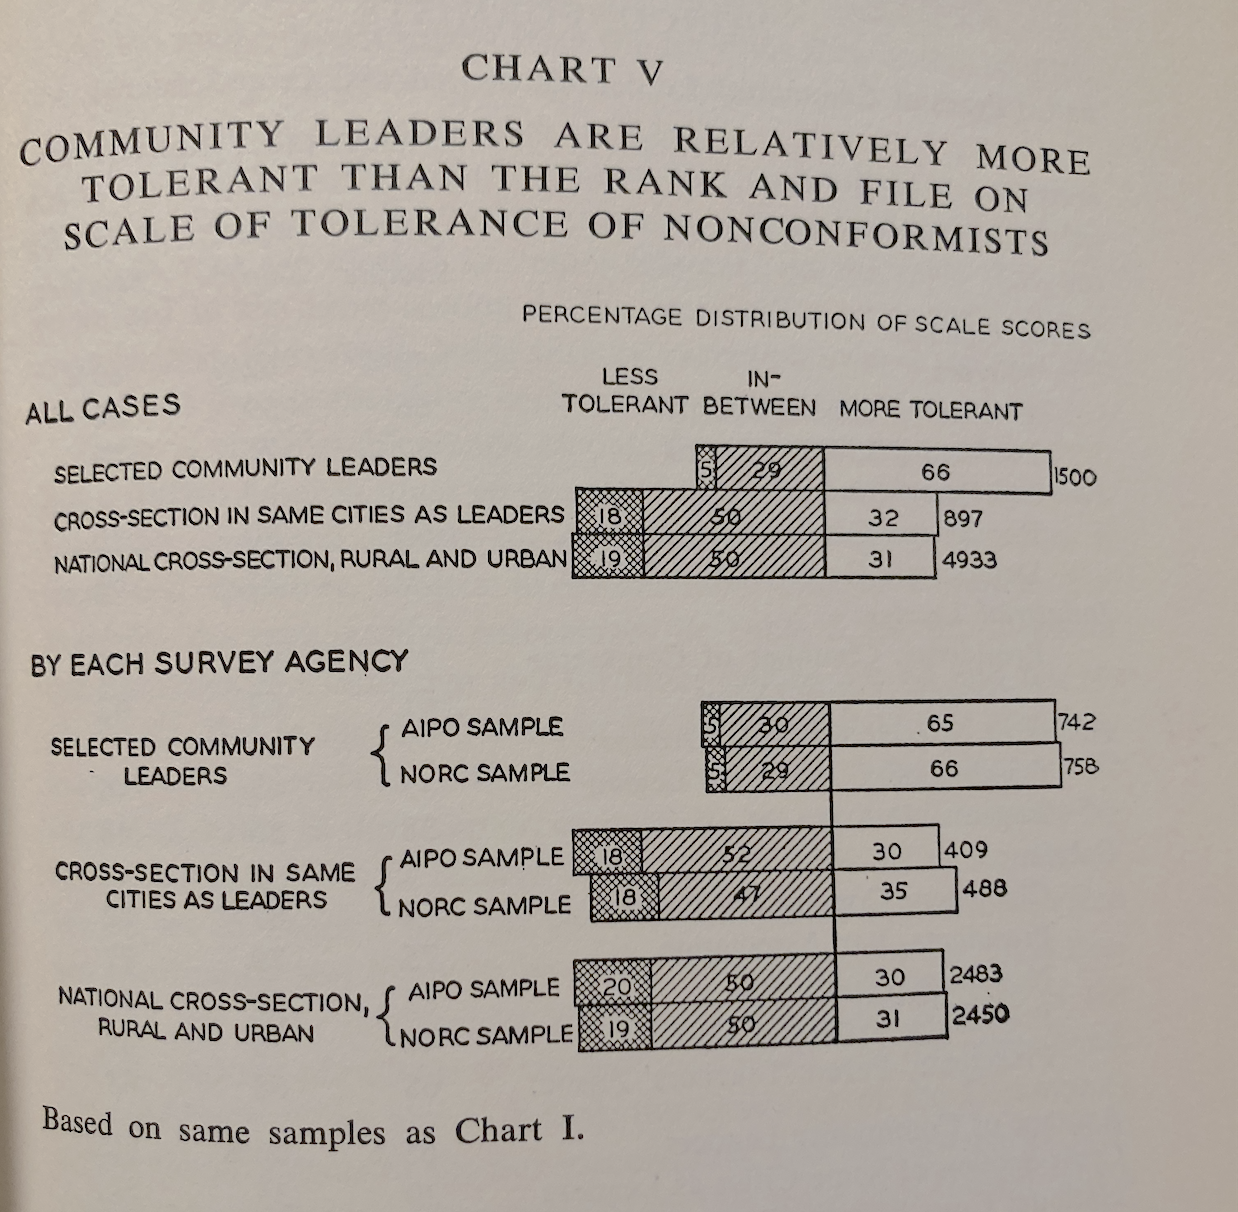{ width="50%"}

##### us region

In [ ]:
code_df <- code_df |> mutate(us_region = case_when(
  v5 %in% c(0, 1) ~ 'east',
  v5 %in% c(2, 3) ~ 'midwest',
  v5 == 4 ~ 'south',
  TRUE ~ 'west'
)
)

In [ ]:
code_df |> filter(leader == 1) |> count(us_region, tolerance_broader) |> group_by(us_region) |> mutate(pct = n / sum(n) * 100) |> ungroup()

  us_region   tolerance_broader       n         pct
  ----------- ------------------- ----- -----------
  east        more tolerant         276   68.148148
  east        in between            107   26.419753
  east        less tolerant          22    5.432099
  midwest     more tolerant         348   69.322709
  midwest     in between            123   24.501992
  midwest     less tolerant          31    6.175299
  south       more tolerant         225   57.251908
  south       in between            123   31.297710
  south       less tolerant          45   11.450382
  west        more tolerant         151   75.500000
  west        in between             38   19.000000
  west        less tolerant          11    5.500000


## Scale2: Scale of the Perception on the Internal Communist Danger

In [ ]:
code_df <- code_df |> mutate(danger = NA_character_)

In [ ]:
code_df <- code_df |> 
  mutate(
    danger5_plus = (v75 == 1),
    danger4_plus = (v66 == 1),
    danger3_plus = (v42 %in% c(1, 2)),
    danger2_plus = (v71 == 8 | v72 %in% c(1, 2, 8)),
    danger1_plus = (v68 == 8 | v69 %in% c(1, 2, 8))
  )
code_df <- code_df |> mutate(
  danger = case_when(
    danger5_plus & (danger4_plus + danger3_plus + danger2_plus + danger1_plus >= 4) ~ "danger5",
    danger4_plus & (danger3_plus + danger2_plus + danger1_plus >= 2) ~ "danger4",
    danger3_plus & (danger2_plus + danger1_plus >= 1) ~ "danger3",
    danger2_plus ~ "danger2",
    (danger5_plus + danger4_plus + danger3_plus + danger2_plus + danger1_plus == 0) ~ "danger0",
    TRUE ~ "danger1"
  )
)

In [ ]:
code_df |> count(danger, .drop = FALSE)

  danger         n
  --------- ------
  danger0      507
  danger1      682
  danger2     2116
  danger3     1170
  danger4     1093
  danger5      865


### Broader rank groups

In [ ]:
code_df <- code_df |> mutate(danger_broader = case_when(
  danger %in% c('danger5', 'danger4') ~ 'great threat',
  danger %in% c('danger3', 'danger2') ~ 'in between',
  TRUE ~ 'little threat'
))

In [ ]:
code_df |> count(danger_broader)

  danger_broader        n
  ---------------- ------
  great threat       1958
  in between         3286
  little threat      1189


In [ ]:
cols_drop <- c("danger5_plus", "danger4_plus", "danger3_plus", "danger2_plus", "danger1_plus")
code_df <- code_df |> dplyr::select(-all_of(cols_drop))

## Evaluating Operationallizations: Reliability and Validity, insights from classfication algorithms

#### Data and Measures: Validity

From the conceptual variable tolerance to the operationalized definition of tolerance, Stouffer proposed *h-technique* to map answers of the respondent to a tolerance score corresponding to their degree of tolerance.\[@stoufferTechniqueImprovingCumulative1952\] But does this tolerance scale really measuring people’s tolerance or is it measuring something else?\[@tesslerSocialScienceResearch2022, pp.43-47\]

#### Reliability

In [ ]:
# df_combined <- read_csv('data/df-combined.csv')
df_combined <- read_csv(file.path(data_dir, 'df-combined.csv'))

Rows: 6433 Columns: 164
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (9): interested, categorizer, tolerance_group, tolerance_broader0, tol...
dbl (155): study_identification, interview_number, type_interview, sample_nu...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

### 3-class classification using the strict measure of tolerance score `tolerance_broader0`

In [ ]:
# df_combined |> colnames() |> View()

In [ ]:
tolerance_df0 <- df_combined |> dplyr::select(-all_of(c("study_identification", "interview_number", "type_interview", 
"sample_number","interested", "categorizer",
"tolerance_group", "tolerance_broader", "tolerance", "danger", "danger_broader")))

In [ ]:
tolerance_df0 |> filter(leader == 1) |> count(tolerance_broader0)

  tolerance_broader0       n
  -------------------- -----
  in between             426
  less tolerant          261
  more tolerant          813


In [ ]:
tolerance_df0$tolerance_broader0 <- factor(tolerance_df0$tolerance_broader0, levels = c("more tolerant","in between", "less tolerant"))

In [ ]:
tolerance_df0 <- tolerance_df0 |>
  mutate(across(-tolerance_broader0, ~ as.factor(.)))

In [ ]:
set.seed(5450)
train_indices <- sample(6433, size = 5146)

trainset <- tolerance_df0 |> slice(train_indices)
testset  <- tolerance_df0 |> slice(-train_indices)

In [ ]:
x_train <- model.matrix(tolerance_broader0~ . - 1, data = trainset)
y_train <- trainset$tolerance_broader0

x_test  <- model.matrix(tolerance_broader0~ . - 1, data = testset)
y_test  <- testset$tolerance_broader0

``` r
clf0 <- cv.glmnet(
  x_train, y_train, family = "multinomial",
  alpha = 1, type.multinomial = "ungrouped"
)

lambda_1se0 <- clf0$lambda.1se
lambda_1se0
# 0.002905948

png("clf0-plot.png", width = 700, height = 600)
plot(clf0)
dev.off()
```

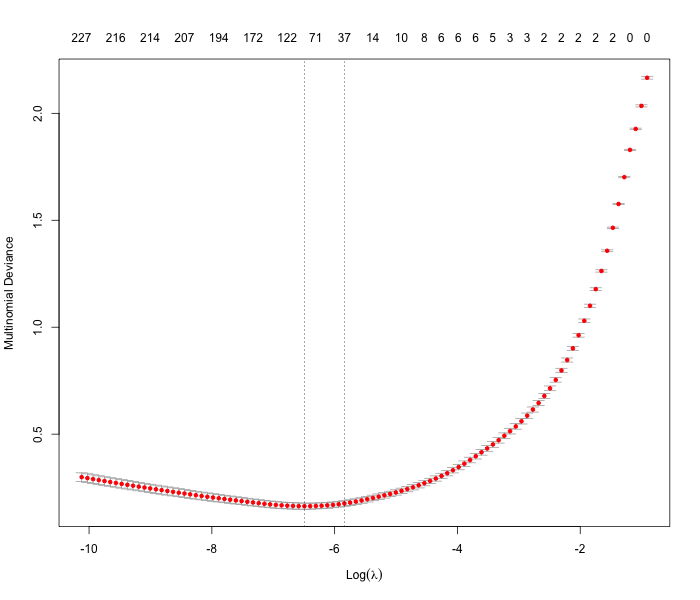{ width="50%"}

In [ ]:
lambda_1se0 <- 0.002905948
clf0 <- glmnet(
  x_train, y_train, family = "multinomial",
  alpha = 1, type.multinomial = "ungrouped",
  lambda = lambda_1se0
)

In [ ]:
yp_train <- predict(clf0, newx = x_train, s = lambda_1se0, type = 'class')
train_acc <- mean(yp_train == y_train)
train_acc

[1] 0.9902837

In [ ]:
yp_test <- predict(clf0, newx = x_test, s = lambda_1se0, type = 'class')
test_acc <- mean(yp_test == y_test)
test_acc

[1] 0.989899

In [ ]:
yp_test <- factor(yp_test, levels = c("more tolerant","in between", "less tolerant"))
y_test  <- factor(y_test, levels = c("more tolerant","in between", "less tolerant"))
lr_cm0 <- confusionMatrix(yp_test, y_test)
lr_cm0

Confusion Matrix and Statistics

               Reference
Prediction      more tolerant in between less tolerant
  more tolerant           400          4             3
  in between                0        511             3
  less tolerant             1          2           363

Overall Statistics
                                          
               Accuracy : 0.9899          
                 95% CI : (0.9828, 0.9946)
    No Information Rate : 0.4017          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.9847          
                                          
 Mcnemar's Test P-Value : 0.1577          

Statistics by Class:

                     Class: more tolerant Class: in between
Sensitivity                        0.9975            0.9884
Specificity                        0.9921            0.9961
Pos Pred Value                     0.9828            0.9942
Neg Pred Value                     0.9989           

In [ ]:
coef_list <- coef(clf0, s = lambda_1se0)

In [ ]:
coefs_df <- map_dfr(names(coef_list), function(class_name) {
  coefs <- coef_list[[class_name]]
  tibble(
    predictor = rownames(coefs),
    coefficient = as.numeric(coefs)
  ) |>
    filter(coefficient != 0) |> 
    arrange(desc(abs(coefficient))) |>
    mutate(
      tolerance_broader0 = class_name,
      rank = row_number()
    ) |>
    dplyr::select(tolerance_broader0, predictor, coefficient, rank)
})
# coefs_df |> write_csv("data/lr-coefs-1se0.csv")

In [ ]:
coefs_df |> count(predictor, sort = TRUE) |> head(12)

  predictor                            n
  ---------------------------------- ---
  (Intercept)                          3
  admitted_communist_allow_speak5      2
  admitted_communist_buy_soap5         2
  admitted_communist_put_jail5         2
  alledged_communist_fire_teacher5     2
  censor_antireligion_book5            2
  censor_antireligion_speaker5         2
  censor_antireligion_speaker8         2
  censor_socialist_book5               2
  censor_socialist_speaker8            2
  many_communists_defense_plants8      2
  many_communists_us5                  2


In [ ]:
test_result <- tibble(
  true_class0 = y_test,
  pred_class0 = yp_test
)

### 3-class classification: `tolerance_broader` based on the measure with wiggle room

In [ ]:
tolerance_df <- df_combined |> dplyr::select(-all_of(c("study_identification", "interview_number", "type_interview", 
"sample_number","interested", "categorizer",
"tolerance_group", "tolerance_broader0", "tolerance", "danger", "danger_broader")))

In [ ]:
tolerance_df$tolerance_broader <- factor(tolerance_df$tolerance_broader, levels = c("more tolerant","in between", "less tolerant"))

In [ ]:
tolerance_df <- tolerance_df |>
  mutate(across(-tolerance_broader, ~ as.factor(.)))

In [ ]:
# set.seed(545)
# train_indices <- sample(6433, size = 5146)

trainset <- tolerance_df |> slice(train_indices)
testset  <- tolerance_df |> slice(-train_indices)

In [ ]:
x_train <- model.matrix(tolerance_broader~ . - 1, data = trainset)
y_train <- trainset$tolerance_broader

x_test  <- model.matrix(tolerance_broader~ . - 1, data = testset)
y_test  <- testset$tolerance_broader

In [ ]:
# x_train |> colnames()

``` r
clf <- cv.glmnet(
  x_train, y_train,family = "multinomial",
  alpha = 1, type.multinomial = "ungrouped"
)
# png("clf-plot.png", width = 700, height = 600)
# plot(clf)
# dev.off()
lambda_best <- clf$lambda.1se
# 0.00391
lambda_seq <- clf$lambda
# saveRDS(lambda_seq, file = "data/clf-lambda-seq.rds")
```

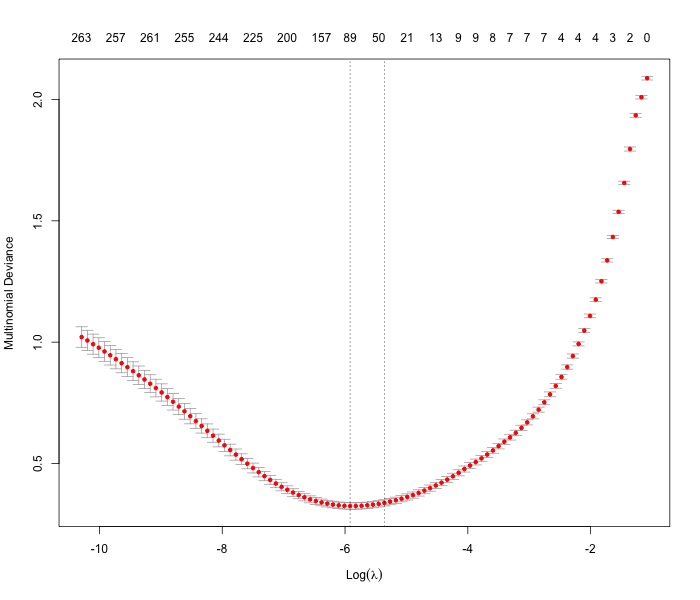

In [ ]:
lambda_1se <- 0.00391
# lambda_seq <- readRDS("data/clf-lambda-seq.rds")
lambda_seq <- readRDS(file.path(data_dir, 'clf-lambda-seq.rds'))
clf <- glmnet(
  x_train, y_train, family = "multinomial",
  alpha = 1, type.multinomial = "ungrouped",
  lambda = lambda_seq
)

In [ ]:
yp_train <- predict(clf, newx = x_train, s = lambda_1se, type = 'class')
train_acc <- mean(yp_train == y_train)
train_acc

[1] 0.958803

In [ ]:
yp_test <- predict(clf, newx = x_test, s = lambda_1se, type = 'class')
test_acc <- mean(yp_test == y_test)
test_acc

[1] 0.950272

In [ ]:
yp_test <- factor(yp_test, levels = c("more tolerant","in between", "less tolerant"))
y_test  <- factor(y_test, levels = c("more tolerant","in between", "less tolerant"))
lr_cm <- confusionMatrix(yp_test, y_test)
lr_cm

Confusion Matrix and Statistics

               Reference
Prediction      more tolerant in between less tolerant
  more tolerant           505          4             5
  in between                9        489            12
  less tolerant             7         27           229

Overall Statistics
                                          
               Accuracy : 0.9503          
                 95% CI : (0.9369, 0.9615)
    No Information Rate : 0.4048          
    P-Value [Acc > NIR] : < 2e-16         
                                          
                  Kappa : 0.9222          
                                          
 Mcnemar's Test P-Value : 0.04548         

Statistics by Class:

                     Class: more tolerant Class: in between
Sensitivity                        0.9693            0.9404
Specificity                        0.9883            0.9726
Pos Pred Value                     0.9825            0.9588
Neg Pred Value                     0.9793           

In [ ]:
coef_list <- coef(clf, s = lambda_1se)

In [ ]:
coefs_df <- map_dfr(names(coef_list), function(class_name) {
  coefs <- coef_list[[class_name]]
  tibble(
    predictor = rownames(coefs),
    coefficient = as.numeric(coefs)
  ) |>
    filter(coefficient != 0) |>
    arrange(desc(abs(coefficient))) |>
    mutate(
      tolerance_broader = class_name,
      rank = row_number()
    ) |>
    dplyr::select(tolerance_broader, predictor, coefficient, rank)
})

# coefs_df |> write_csv("lr-coefs-1se.csv")

In [ ]:
coefs_df |> count(predictor, sort = TRUE) |> head(12)

  predictor                                        n
  ---------------------------------------------- ---
  (Intercept)                                      3
  admitted_communist_allow_speak5                  2
  admitted_communist_buy_soap5                     2
  admitted_communist_put_jail5                     2
  admitted_communist_remove_book_library5          2
  alledged_communist_fire_clerk5                   2
  alledged_communist_fire_clerk8                   2
  alledged_communist_fire_defense_plant5           2
  alledged_communist_fire_high_school_teacher5     2
  alledged_communist_fire_singer5                  2
  alledged_communist_fire_teacher5                 2
  alledged_communist_make_community_speech5        2


### Are these selected Items capturing most of the variances?

In [ ]:
# label_lookup <- read_csv('data/gbv_labels.csv')
label_lookup <- read_csv(file.path(data_dir, 'gbv_labels.csv'))

Rows: 152 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): v_name, v_label

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

In [ ]:
tolerance_item_labels <- label_lookup |> filter(v_name %in% tolerance_items) |> pull(v_label)

In [ ]:
# tolerance_item_labels |> View()

### Learning: Predicting Tolerance Score without the original 15 items

In [ ]:
tolerance_items <- c(
  'v100', 'v101', 'v102',
  'v104', 'v32', 'v34',
  'v103', 'v35', 'v37',
  'v108', 'v109', 'v113',
  'v106', 'v107', 'v110'
)

In [ ]:
# label_lookup <- read_csv('data/gbv_labels.csv')
label_lookup <- read_csv(file.path(data_dir, 'gbv_labels.csv'))

Rows: 152 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): v_name, v_label

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

In [ ]:
tolerance_item_labels <- label_lookup |> filter(v_name %in% tolerance_items) |> pull(v_label)

In [ ]:
tolerance_df3 <- df_combined |> dplyr::select(-all_of(c("study_identification", "interview_number", "type_interview", 
"sample_number","interested", "categorizer",
"tolerance_group", "tolerance_broader", "tolerance", "danger", "danger_broader")))
tolerance_df3 <- tolerance_df3 |> dplyr::select(-all_of(tolerance_item_labels))

In [ ]:
tolerance_df3 |> filter(leader == 1) |> count(tolerance_broader0)

  tolerance_broader0       n
  -------------------- -----
  in between             426
  less tolerant          261
  more tolerant          813


In [ ]:
tolerance_df3$tolerance_broader0 <- factor(tolerance_df3$tolerance_broader0, levels = c("more tolerant","in between", "less tolerant"))

In [ ]:
tolerance_df3 <- tolerance_df3 |>
  mutate(across(-tolerance_broader0, ~ as.factor(.)))

In [ ]:
trainset <- tolerance_df3 |> slice(train_indices)
testset  <- tolerance_df3 |> slice(-train_indices)

In [ ]:
x_train <- model.matrix(tolerance_broader0~ . - 1, data = trainset)
y_train <- trainset$tolerance_broader0

x_test  <- model.matrix(tolerance_broader0~ . - 1, data = testset)
y_test  <- testset$tolerance_broader0

In [ ]:
# x_train |> colnames()

``` r
clf3 <- cv.glmnet(
  x_train, y_train, family = "multinomial",
  alpha = 0.75, type.multinomial = "ungrouped"
)
lambda_1se3 <- clf3$lambda.1se
lambda_1se3
# 0.01726083
lambda_seq3 <- clf3$lambda
# saveRDS(lambda_seq3, file = "data/clf3-lambda-seq.rds")

# png("image/clf3-plot.png", width = 700, height = 600)
# plot(clf3)
# dev.off()
```

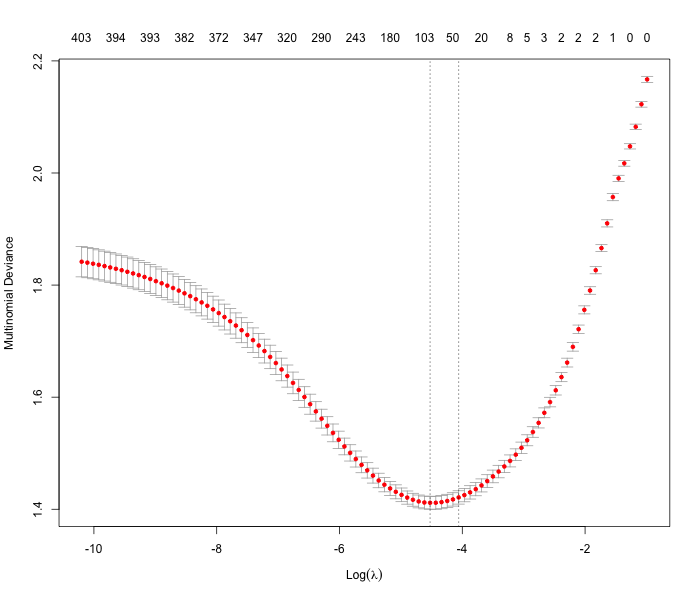

In [ ]:
lambda_1se3 <- 0.01726083
# lambda_seq3 <- readRDS("data/clf3-lambda-seq.rds")
lambda_seq3 <- readRDS(file.path(data_dir, 'clf3-lambda-seq.rds'))
clf3 <- glmnet(
  x_train, y_train, family = "multinomial",
  alpha = 1, type.multinomial = "ungrouped",
  lambda = lambda_seq3
)

In [ ]:
yp_train <- predict(clf3, newx = x_train, s = lambda_1se3, type = 'class')
train_acc <- mean(yp_train == y_train)
train_acc

[1] 0.7188107

In [ ]:
yp_test <- predict(clf3, newx = x_test, s = lambda_1se3, type = 'class')
test_acc <- mean(yp_test == y_test)
test_acc

[1] 0.6985237

In [ ]:
yp_test <- factor(yp_test, levels = c("more tolerant","in between", "less tolerant"))
y_test  <- factor(y_test, levels = c("more tolerant","in between", "less tolerant"))
lr_cm0 <- confusionMatrix(yp_test, y_test)
lr_cm0

Confusion Matrix and Statistics

               Reference
Prediction      more tolerant in between less tolerant
  more tolerant           264         65            39
  in between              125        435           130
  less tolerant            12         17           200

Overall Statistics
                                          
               Accuracy : 0.6985          
                 95% CI : (0.6726, 0.7235)
    No Information Rate : 0.4017          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.5322          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       

Statistics by Class:

                     Class: more tolerant Class: in between
Sensitivity                        0.6584            0.8414
Specificity                        0.8826            0.6688
Pos Pred Value                     0.7174            0.6304
Neg Pred Value                     0.8509           

### Acquired the class specific variables and their coefficients

In [ ]:
coef_list <- coef(clf3, s = lambda_1se3)

In [ ]:
coefs_df <- map_dfr(names(coef_list), function(class_name) {
  coefs <- coef_list[[class_name]]
  tibble(
    predictor = rownames(coefs),
    coefficient = as.numeric(coefs)
  ) |>
    filter(coefficient != 0) |> 
    arrange(desc(abs(coefficient))) |>
    mutate(
      tolerance_broader0 = class_name,
      rank = row_number()
    ) |>
    dplyr::select(tolerance_broader0, predictor, coefficient, rank)
})
# coefs_df |> write_csv("data/lr-coefs-1se3.csv")

In [ ]:
coefs_df |> count(predictor, sort = TRUE) |> head(12)

  predictor                                      n
  -------------------------------------------- ---
  (Intercept)                                    3
  admitted_communist_fire_clerk5                 2
  admitted_communist_lose_citizenship5           2
  break_friendship_former_communist5             2
  censor_antireligion_teacher5                   2
  child_rearing_respect3                         2
  last_grade_finished_school5                    2
  remember_hiss_caught8                          2
  admitted_communist_fire_college_professor5     1
  admitted_communist_lose_citizenship8           1
  alledged_communist_buy_soap5                   1
  alledged_communist_fire_singer5                1


### Worrying about Internal Communist Threats

In [ ]:
toler_rigid_tb <- table(df_combined$tolerance_group, df_combined$categorizer)
chi_test <- chisq.test(toler_rigid_tb)
chi_test


    Pearson's Chi-squared test

data:  toler_rigid_tb
X-squared = 491.09, df = 10, p-value < 2.2e-16

In [ ]:
chi_test$residuals

            
                  agree   disagree  dont know
  tolerance0  3.6776281 -5.3964437  1.1128421
  tolerance1 -2.3955483 -1.0211719 10.7874512
  tolerance2  4.5040579 -6.1915000  0.3030713
  tolerance3  2.7420911 -2.5744267 -2.8481376
  tolerance4 -0.6175252  2.2641002 -3.6331099
  tolerance5 -7.2561266 11.9240239 -5.4354457

In [ ]:
toler_danger_tb <- table(df_combined$tolerance_group, df_combined$danger)
chi_test <- chisq.test(toler_danger_tb)
chi_test


    Pearson's Chi-squared test

data:  toler_danger_tb
X-squared = 410.67, df = 25, p-value < 2.2e-16

In [ ]:
chi_test$residuals

            
                  danger0      danger1      danger2      danger3      danger4
  tolerance0 -2.970715176 -2.658964979 -2.459910036  0.974739884  2.152232514
  tolerance1 -4.609232171 -1.006527133  4.547776892 -1.482352369  0.006717332
  tolerance2 -3.631408736 -5.657972356  0.475321324  2.009535358  1.330107400
  tolerance3 -0.858497500 -0.790142288 -1.598983893  2.256620306  1.165660786
  tolerance4  0.394465523  0.926642029 -0.167803951  0.370962087 -0.093407449
  tolerance5 10.328080755  8.630383914 -1.058231155 -3.774441827 -3.913075010
            
                  danger5
  tolerance0  4.929822736
  tolerance1 -0.973974888
  tolerance2  3.228408105
  tolerance3 -0.075048875
  tolerance4 -1.188784303
  tolerance5 -5.126832308

In [ ]:
residuals_df <- as_tibble(as.table(chi_test$residuals), .name_repair = 'minimal') |>
  rename(
    tolerance = 1,
    danger = 2,
    residual = n
  )

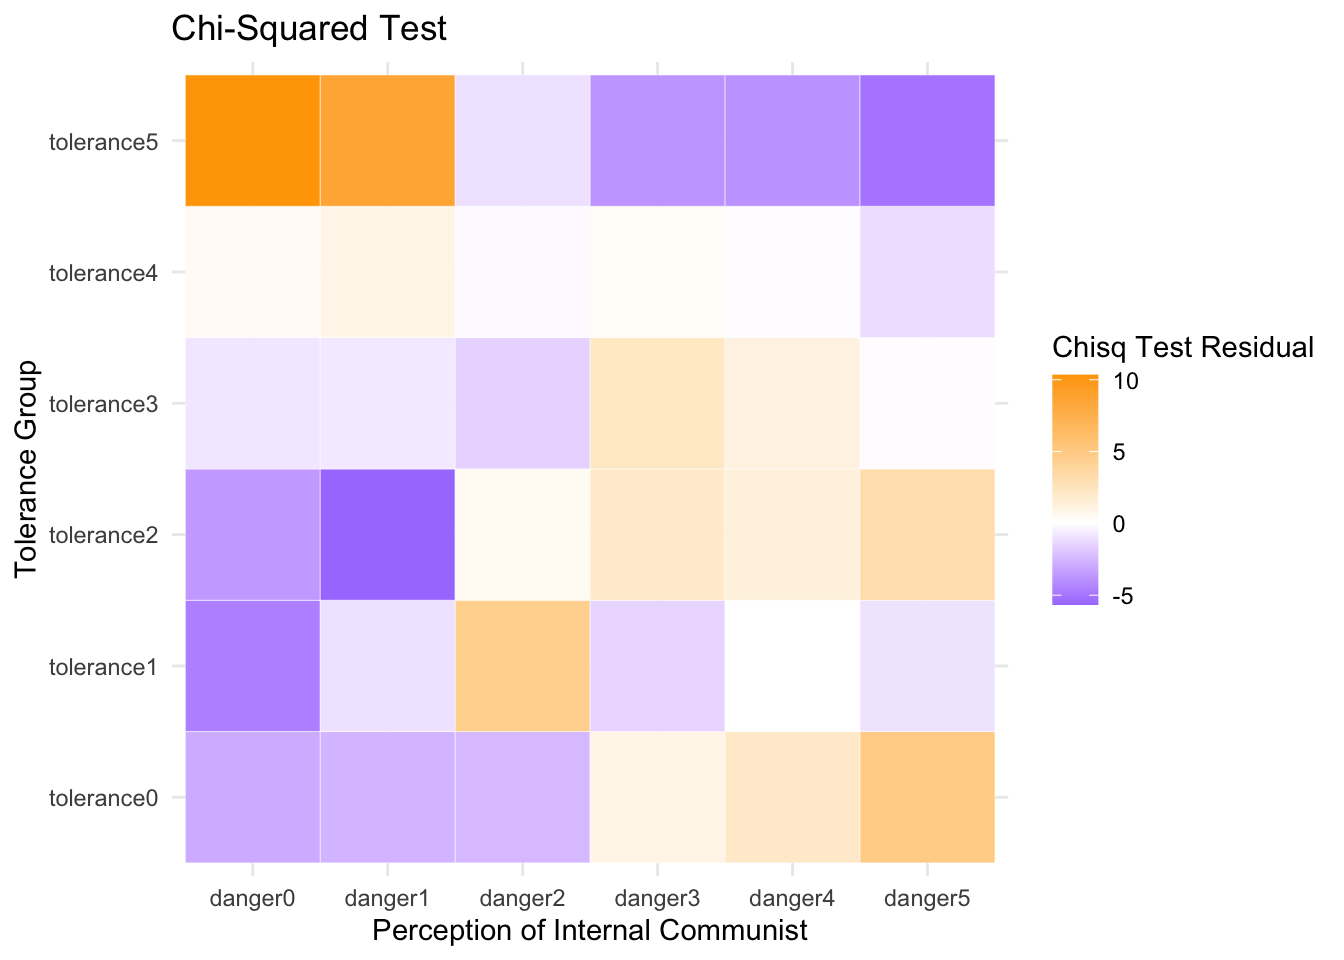

In [ ]:
residuals_df |> ggplot(aes(x = danger, y = tolerance, fill = residual)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "blue", mid = "white", high = "orange", midpoint = 0, limit = c(min(residuals_df$residual), max(residuals_df$residual)), name = "Chisq Test Residual") +
  labs(
    title = "Chi-Squared Test",
    x = "Perception of Internal Communist",
    y = "Tolerance Group"
  ) +
  theme_minimal()

## Results

### Reflections

## Policy Recommendation